# Pandas 데이터 분석 연습 문제: 시애틀 자전거 통행량

이 문제는 시애틀의 Fremont Bridge 자전거 통행량 데이터를 분석하는 연습을 제공합니다. pandas를 활용하여 데이터 전처리, 날짜 기반 분석, 날씨 데이터 병합 및 상관관계 분석을 수행합니다. (p234 참고)

---

<img src="https://images.seattletimes.com/wp-content/uploads/2020/01/01022020_bike-count_114545.jpg?d=2040x1360" width=400>

Ken Lambert, "Bike ridership hits record highs on 2 Seattle routes", The Seattle Times, Jan. 6, 2020


## 1. 자전거 통행량 데이터 기본 전처리

FremontBridge.csv 파일을 사용하여 시애틀 다리의 자전거 통행량 데이터를 불러오고 기본적인 전처리 작업을 수행합니다.

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




### 1.1 데이터 읽기

- **목표**: FremontBridge.csv 파일을 pandas DataFrame으로 읽어와 df_bike 변수에 저장합니다.
- **힌트**:
    - pandas의 read_csv 함수를 사용하세요.
    - 파일의 경로와 이름을 인자로 전달합니다. (url: 'https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/FremontBridge.csv')



In [128]:
df = pd.read_csv('https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/FremontBridge.csv')

### 1.2 데이터 미리보기

- **목표**: df_bike DataFrame의 처음 5개 행을 출력하여 데이터 구조와 값을 확인합니다.
- **힌트**:
    - DataFrame의 head 메서드를 사용하면 처음 5개 행을 확인할 수 있습니다.



In [129]:
df.head()

,Date,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
0,11/01/2019 12:00:00 AM,12.0,7.0,5.0
1,11/01/2019 01:00:00 AM,7.0,0.0,7.0
2,11/01/2019 02:00:00 AM,1.0,0.0,1.0
3,11/01/2019 03:00:00 AM,6.0,6.0,0.0
4,11/01/2019 04:00:00 AM,6.0,5.0,1.0


### 1.3 데이터 요약 정보 확인

- **목표**: df_bike DataFrame의 컬럼명, 데이터 타입, 유효 값 개수, 메모리 사용량 등 요약 정보를 확인합니다.
- **힌트**:
    - DataFrame의 info 메서드를 호출하여 요약 정보를 확인하세요.



In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147278 entries, 0 to 147277
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date                          147278 non-null  object 
 1   Fremont Bridge Total          147256 non-null  float64
 2   Fremont Bridge East Sidewalk  147256 non-null  float64
 3   Fremont Bridge West Sidewalk  147255 non-null  float64
dtypes: float64(3), object(1)
memory usage: 4.5+ MB


### 1.4 데이터 타입 및 누락값 상세 확인

- **목표**: 각 컬럼의 데이터 타입과 누락값(NaN)의 개수를 확인합니다.
- **힌트**:
    - 데이터 타입은 dtypes 속성으로 확인합니다.
    - 누락값은 isnull 메서드와 sum 메서드를 조합하여 컬럼별 합계를 계산합니다.



In [131]:
df.dtypes, df.isnull().sum()

(Date                             object
 Fremont Bridge Total            float64
 Fremont Bridge East Sidewalk    float64
 Fremont Bridge West Sidewalk    float64
 dtype: object,
 Date                             0
 Fremont Bridge Total            22
 Fremont Bridge East Sidewalk    22
 Fremont Bridge West Sidewalk    23
 dtype: int64)

### 1.5 컬럼명 변경

- **목표**: df_bike DataFrame의 컬럼명을 다음과 같이 변경합니다:
    - Fremont Bridge Total → Total
    - Fremont Bridge East Sidewalk → East
    - Fremont Bridge West Sidewalk → West

In [132]:
df = df.rename(columns={"Fremont Bridge Total":"Total",
                    "Fremont Bridge East Sidewalk":"East",
                    "Fremont Bridge West Sidewalk":"West"})
df.head()

,Date,Total,East,West
0,11/01/2019 12:00:00 AM,12.0,7.0,5.0
1,11/01/2019 01:00:00 AM,7.0,0.0,7.0
2,11/01/2019 02:00:00 AM,1.0,0.0,1.0
3,11/01/2019 03:00:00 AM,6.0,6.0,0.0
4,11/01/2019 04:00:00 AM,6.0,5.0,1.0


### 1.6 'Date' 컬럼 타입 변경

- **목표**: Date 컬럼을 문자열(object)에서 datetime 형식으로 변환하여 df_bike['Date']에 할당합니다.
- **힌트**:
    - pandas의 to_datetime 함수에 df_bike['Date']를 전달하여 변환합니다.



In [133]:
df["Date"] = pd.to_datetime(df["Date"])
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_13468\111811861.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Total,East,West
0,2019-11-01 00:00:00,12.0,7.0,5.0
1,2019-11-01 01:00:00,7.0,0.0,7.0
2,2019-11-01 02:00:00,1.0,0.0,1.0
3,2019-11-01 03:00:00,6.0,6.0,0.0
4,2019-11-01 04:00:00,6.0,5.0,1.0


In [134]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147278 entries, 0 to 147277
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   Date    147278 non-null  datetime64[ns]
 1   Total   147256 non-null  float64       
 2   East    147256 non-null  float64       
 3   West    147255 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 4.5 MB
None


### 1.7 'Date' 컬럼을 인덱스로 설정

- **목표**: datetime 형식으로 변환된 Date 컬럼을 df_bike의 행 인덱스로 설정합니다.
- **힌트**:
    - set_index 메서드에 Date 컬럼명을 전달합니다.



In [135]:
df = df.set_index(keys="Date")

### 1.8 누락값 처리

- **목표**: Total, East, West 컬럼의 누락값(NaN)을 각 컬럼의 평균값으로 채웁니다.
- **힌트**:
    - 각 컬럼에 fillna 메서드를 사용하고, 채울 값으로 해당 컬럼의 mean 값을 전달합니다.


In [136]:
df = df.fillna(df.mean(axis=0))



## 2. 날짜 관련 데이터 분석 (자전거 통행량)

시간 정보를 활용하여 자전거 통행량의 패턴을 분석하고 시각화합니다.



### 2.1 주간 단위 총 통행량 시각화

- **목표**: Total 컬럼의 일별 통행량을 주간 단위로 합산하여 선 그래프(line plot)로 시각화합니다.
- **힌트**:
    - Total 컬럼을 선택한 후 resample('W')로 주간 단위로 그룹화하고 sum으로 합계를 계산합니다.
    - plot 메서드로 선 그래프를 그립니다.



<Axes: xlabel='Date'>

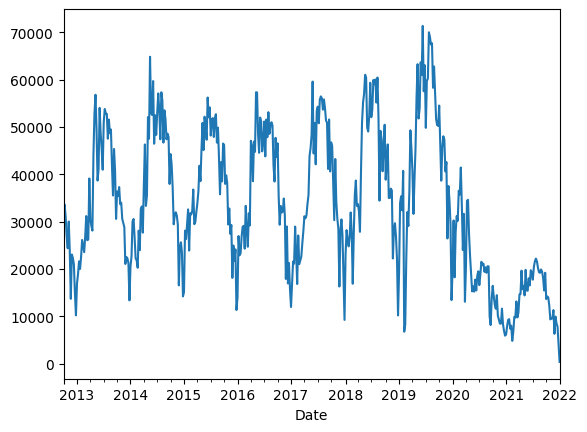

In [140]:
df['Total'].resample('W').sum().plot()

### 2.2 시간대별 평균 통행량 시각화

- **목표**: 하루 24시간(0~23시)별 평균 Total 통행량을 계산하고 막대 그래프(bar plot)로 시각화합니다.
- **힌트**:
    - 인덱스의 시간 정보(df_bike.index.hour)를 기준으로 groupby 연산을 수행합니다.
    - Total 컬럼의 mean 값을 계산하고 plot(kind='bar')로 막대 그래프를 그립니다.



<Axes: xlabel='Date'>

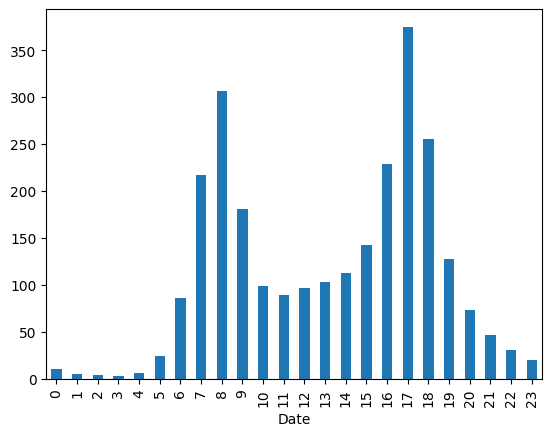

In [ ]:
df.groupby(df.index.hour)['Total'].mean().plot(kind="bar") # df.index.hour => DateTime으로 바꾸고 index로 만들었기 때문에 가능한 것임

### 2.3 요일별 평균 통행량 시각화

- **목표**: 요일별(월~일) 평균 Total 통행량을 계산하고 막대 그래프로 시각화합니다.
- **힌트**:
    - 인덱스의 요일 이름(df_bike.index.day_name())을 기준으로 groupby 연산을 수행합니다.
    - Total 컬럼의 mean 값을 계산하고 plot(kind='bar')로 막대 그래프를 그립니다.



<Axes: xlabel='Date'>

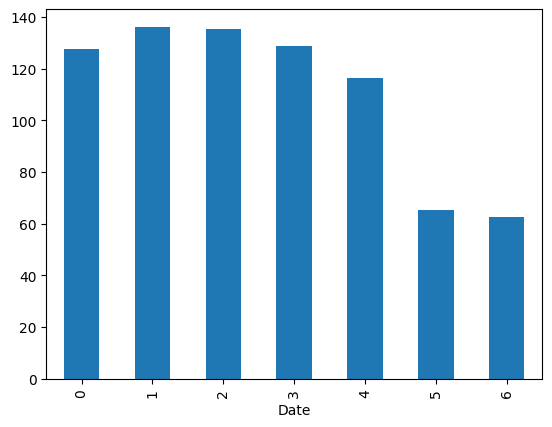

In [151]:
# weekday => Monday is 0 and Sunday is 6
df.groupby(df.index.weekday)['Total'].mean().plot(kind='bar')

In [ ]:
# weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# df['weekday'] = 

### 2.4 요일 및 시간대별 평균 통행량 (Pivot Table)

- **목표**: 피벗 테이블을 사용하여 시간대(행)와 요일(열)에 따른 평균 Total 통행량 표를 생성합니다.
- **힌트**:
    - pivot_table 메서드에서 values='Total', index=df_bike.index.hour, columns=df_bike.index.day_name(), aggfunc='mean'을 지정합니다.



In [152]:
df.pivot_table(values="Total", index=df.index.hour, columns=df.index.day_name(), aggfunc='mean')

Date,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Date,,,,,,,
0,11.901938,6.802511,16.455479,14.614857,9.579727,8.369863,8.864619
1,6.034208,3.238584,9.526256,8.358857,4.739180,4.013699,4.564278
2,3.391106,2.295662,6.101598,7.162024,3.257403,3.030822,3.056883
3,2.785633,2.200913,3.488584,3.210286,2.735763,2.509132,2.712173
4,6.964652,7.186073,4.114155,3.278857,7.370159,7.641553,8.062571
5,27.610034,31.690639,8.675799,5.840000,32.132118,34.252283,33.614334
6,97.302166,110.699772,19.342466,14.380571,113.783599,126.713470,123.362912
7,245.484607,284.553653,35.808219,29.066286,286.935080,322.860731,312.348123
8,350.470924,406.699772,65.644977,54.014857,403.084282,441.309361,425.001138


### 2.5 30일 이동 평균 통행량 시각화

- **목표**: Total 통행량의 30일 이동 평균을 계산하고 선 그래프로 시각화합니다.
- **힌트**:
    - Total 컬럼에 rolling(window=30)을 적용하고 mean으로 평균을 계산합니다.
    - plot 메서드로 선 그래프를 그립니다.



<Axes: xlabel='Date'>

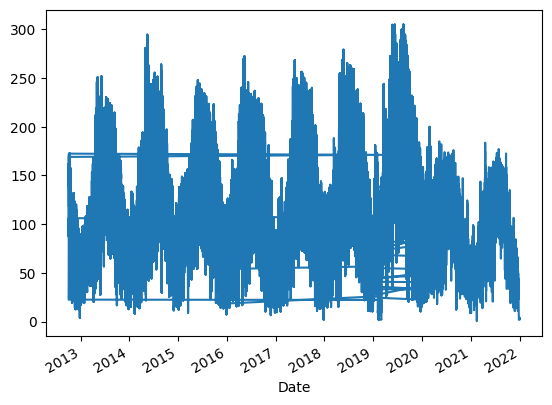

In [154]:
df['Total'].rolling(window=30).mean().plot()

## 3. 날씨 데이터 병합 및 분석

SeattleWeather.csv 파일의 날씨 데이터를 읽어와 자전거 통행량 데이터와 병합하여 날씨와 통행량의 관계를 분석합니다.


### 3.1 날씨 데이터 읽기 및 기본 전처리

- **목표**:
    - SeattleWeather.csv 파일을 df_weather DataFrame으로 읽습니다. (url: https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/SeattleWeather.csv)
    - DATE 컬럼을 datetime 형식으로 변환하고 인덱스로 설정합니다.
    - PRCP 컬럼의 누락값을 0으로 채웁니다.


In [164]:
df_weather = pd.read_csv('https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/SeattleWeather.csv')

In [165]:
df_weather.head()

,STATION,NAME,DATE,AWND,FMTM,PGTM,PRCP,SNOW,SNWD,TAVG,...,WT04,WT05,WT08,WT09,WT13,WT14,WT16,WT17,WT18,WT22
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-01,10.51,NaN,NaN,0.00,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-02,10.07,NaN,NaN,0.43,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-03,5.14,NaN,NaN,0.03,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-04,10.51,NaN,NaN,0.80,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN
4,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-05,13.65,NaN,NaN,0.05,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [157]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 29 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3653 non-null   object 
 1   NAME     3653 non-null   object 
 2   DATE     3653 non-null   object 
 3   AWND     3653 non-null   float64
 4   FMTM     31 non-null     float64
 5   PGTM     83 non-null     float64
 6   PRCP     3650 non-null   float64
 7   SNOW     3653 non-null   float64
 8   SNWD     3653 non-null   float64
 9   TAVG     3197 non-null   float64
 10  TMAX     3653 non-null   int64  
 11  TMIN     3653 non-null   int64  
 12  WDF2     3653 non-null   int64  
 13  WDF5     3615 non-null   float64
 14  WSF2     3653 non-null   float64
 15  WSF5     3615 non-null   float64
 16  WT01     1630 non-null   float64
 17  WT02     187 non-null    float64
 18  WT03     38 non-null     float64
 19  WT04     10 non-null     float64
 20  WT05     4 non-null      float64
 21  WT08     215 n

In [ ]:
df_weather['DATE'] = pd.to_datetime(df_weather['DATE'])
df_weather

,STATION,NAME,DATE,AWND,FMTM,PGTM,PRCP,SNOW,SNWD,TAVG,...,WT04,WT05,WT08,WT09,WT13,WT14,WT16,WT17,WT18,WT22
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-01,10.51,NaN,NaN,0.00,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-02,10.07,NaN,NaN,0.43,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-03,5.14,NaN,NaN,0.03,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-04,10.51,NaN,NaN,0.80,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN
4,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2012-01-05,13.65,NaN,NaN,0.05,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3648,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-27,9.62,NaN,NaN,0.03,0.5,3.1,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3649,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-28,8.50,NaN,NaN,NaN,1.0,2.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3650,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-29,8.50,NaN,NaN,0.13,0.9,2.0,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3651,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2021-12-30,9.62,NaN,NaN,NaN,3.4,3.1,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [167]:
df_weather = df_weather.set_index(keys='DATE')
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2012-01-01 to 2021-12-31
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3653 non-null   object 
 1   NAME     3653 non-null   object 
 2   AWND     3653 non-null   float64
 3   FMTM     31 non-null     float64
 4   PGTM     83 non-null     float64
 5   PRCP     3650 non-null   float64
 6   SNOW     3653 non-null   float64
 7   SNWD     3653 non-null   float64
 8   TAVG     3197 non-null   float64
 9   TMAX     3653 non-null   int64  
 10  TMIN     3653 non-null   int64  
 11  WDF2     3653 non-null   int64  
 12  WDF5     3615 non-null   float64
 13  WSF2     3653 non-null   float64
 14  WSF5     3615 non-null   float64
 15  WT01     1630 non-null   float64
 16  WT02     187 non-null    float64
 17  WT03     38 non-null     float64
 18  WT04     10 non-null     float64
 19  WT05     4 non-null      float64
 20  WT08     215 non-null    float64
 

In [173]:
df_weather['PRCP'] = df_weather["PRCP"].fillna(0)

In [174]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2012-01-01 to 2021-12-31
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3653 non-null   object 
 1   NAME     3653 non-null   object 
 2   AWND     3653 non-null   float64
 3   FMTM     31 non-null     float64
 4   PGTM     83 non-null     float64
 5   PRCP     3653 non-null   float64
 6   SNOW     3653 non-null   float64
 7   SNWD     3653 non-null   float64
 8   TAVG     3197 non-null   float64
 9   TMAX     3653 non-null   int64  
 10  TMIN     3653 non-null   int64  
 11  WDF2     3653 non-null   int64  
 12  WDF5     3615 non-null   float64
 13  WSF2     3653 non-null   float64
 14  WSF5     3615 non-null   float64
 15  WT01     1630 non-null   float64
 16  WT02     187 non-null    float64
 17  WT03     38 non-null     float64
 18  WT04     10 non-null     float64
 19  WT05     4 non-null      float64
 20  WT08     215 non-null    float64
 

### 3.2 데이터프레임 병합 (Merge)

- **목표**: df_bike와 df_weather를 날짜 인덱스를 기준으로 병합하여 df_merged에 저장합니다.
- **힌트**:
    - pd.merge 함수에 df_bike, df_weather, left_index=True, right_index=True 옵션을 전달합니다.



In [179]:
# pd.merge(df, df_weather, how="inner" left_index='Date', right_index='DATE') 이건 date를 index로 바꿨으니 못함
df_merged = pd.merge(df, df_weather, how='left', left_index=True, right_index=True) 
print(df_merged.shape)
cols = ['Total', 'East', 'West', 'PRCP']
df_merged[cols].head()

(147278, 31)


,Total,East,West,PRCP
Date,,,,
2019-11-01 00:00:00,12.0,7.0,5.0,0.0
2019-11-01 01:00:00,7.0,0.0,7.0,NaN
2019-11-01 02:00:00,1.0,0.0,1.0,NaN
2019-11-01 03:00:00,6.0,6.0,0.0,NaN
2019-11-01 04:00:00,6.0,5.0,1.0,NaN


### 3.3 강수량과 자전거 통행량 관계 분석

- **목표**:
    - PRCP와 Total 간의 관계를 산점도(scatter plot)로 시각화합니다.
    - 두 변수의 상관계수를 계산합니다.
- **힌트**:
    - df_merged.plot.scatter로 산점도를 그립니다.
    - sns.scatterplot 로 산점도를 그립니다.
    - df_merged['PRCP'].corr 로 상관계수를 계산합니다.



<Axes: xlabel='PRCP', ylabel='Total'>

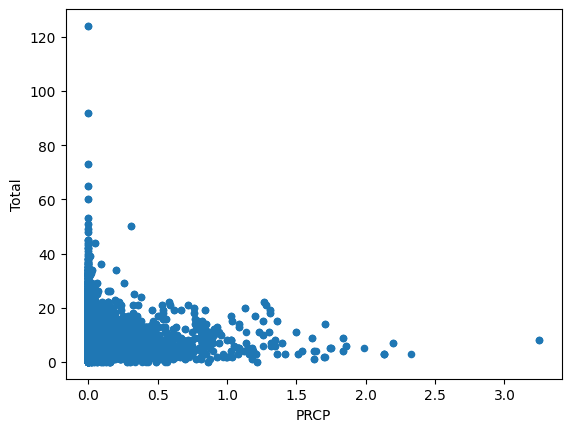

In [180]:
df_merged.plot.scatter(x='PRCP', y='Total')

### 3.4 기온과 자전거 통행량 관계 분석

- **목표**: TAVG(또는 TMAX, TMIN)와 Total 간의 관계를 산점도 또는 구간별 평균 통행량으로 분석합니다.
- **힌트**:
    - 산점도는 df_merged.plot.scatter(x='TAVG', y='Total')로 그립니다.
    - 구간별 분석은 pd.cut으로 기온을 구간화하고 groupby로 평균을 계산한 후 plot으로 시각화합니다.


In [183]:
df_merged[['TAVG', 'Total']].resample('D').mean().shape

(3377, 2)

<Axes: xlabel='TAVG', ylabel='Total'>

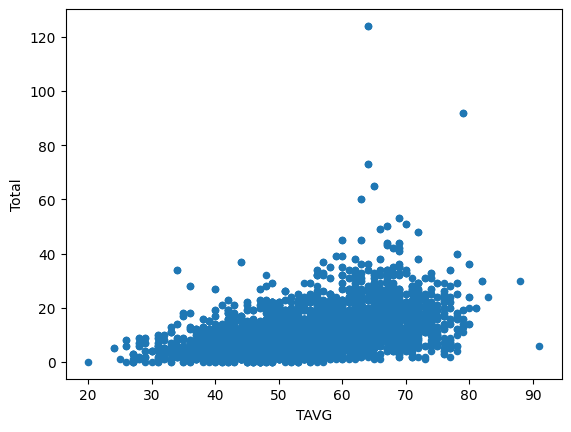

In [181]:
df_merged.plot.scatter(x='TAVG', y='Total')


### 3.5 날씨 조건에 따른 통행량 비교

- **목표**: 비가 온 날(PRCP > 0)과 비가 오지 않은 날(PRCP = 0)의 평균 Total 통행량을 비교합니다.
- **힌트**:
    - 불리언 인덱싱으로 조건 (비가 온 날과 비가 오지 않은 날)을 설정합니다.

In [184]:
mask_rain = 0 < df_merged['PRCP']
mask_wo_rain = df_merged['PRCP'] == 0

In [ ]:
df_merged.loc[mask_rain, :].shape # 풀어서 쓰는 경우가 많음, 나중에 봤을 때 필터를 쓴다는 것을 이해하기 쉬울려고

(2673, 31)

In [190]:
df_merged.loc[mask_rain].shape

(2673, 31)